In [27]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [11]:
data = pd.read_csv("../data/clean/cleaned_data.csv")

In [14]:
data["avg_monthly_charge"] = np.where(
    data["tenure_months"] > 0,
    data["total_charges"] / data["tenure_months"],
    data["monthly_charges"]
)

In [26]:
print(data[
    [
        "customerid",
        "tenure_months",
        "monthly_charges",
        "total_charges",
        "avg_monthly_charge",
        "churn_value"
    ]
].sample(100))

      customerid  tenure_months  monthly_charges  total_charges  \
3730  8869-LIHMK             64           115.10        7334.05   
3717  6061-GWWAV             41            70.20        2894.55   
6504  9541-PWTWO             52            80.95        4233.95   
6223  8514-VZHEB             59            19.50        1147.85   
267   9948-YPTDG             38            79.45        3013.05   
3002  2882-WDTBA             69            75.75        5388.15   
1634  4789-KWMXN             47           110.85        5275.80   
2287  3716-UVSPD              1            49.30          49.30   
4504  2227-JRSJX             21            99.15        1956.40   
6210  7054-ENNGU              9            50.85         466.60   
4235  3810-DVDQQ             72           117.60        8308.90   
3605  2789-HQBOU              3            80.35         253.80   
401   3703-VAVCL              2            90.00         190.05   
2783  2788-CJQAQ             13            19.45         270.2

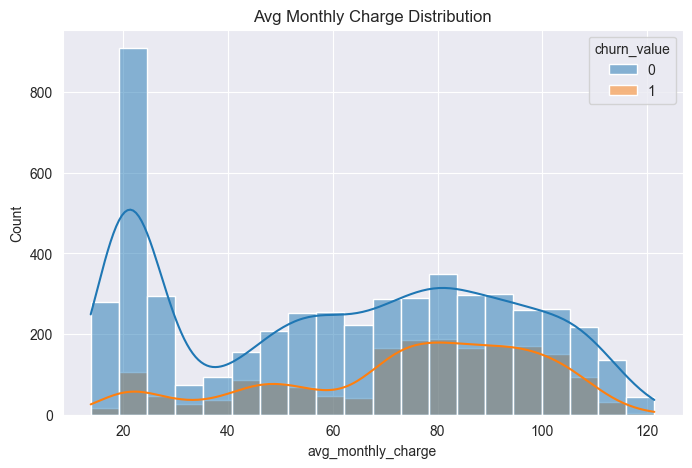

In [29]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=data,
    x="avg_monthly_charge",
    hue="churn_value",
    kde=True
)

plt.title("Avg Monthly Charge Distribution")
plt.show()

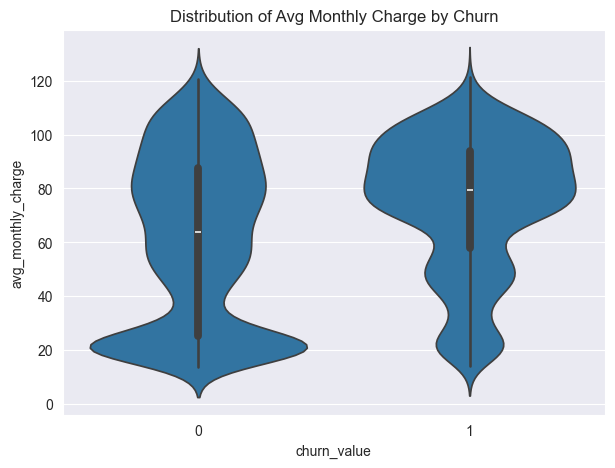

In [30]:
plt.figure(figsize=(7,5))

sns.violinplot(
    x="churn_value",
    y="avg_monthly_charge",
    data=data
)

plt.title("Distribution of Avg Monthly Charge by Churn")
plt.show()

In [34]:
global_avg = data["monthly_charges"].mean()
data["charge_vs_avg"] = data["monthly_charges"] - global_avg

print(data[
    [
        "customerid",
        "monthly_charges",
        "charge_vs_avg",
        "churn_value",
        "churn_reason"
    ]
].sample(100))

      customerid  monthly_charges  charge_vs_avg  churn_value  \
6537  6048-QBXKL            56.55      -8.211692            0   
6805  2452-MRMZF            25.70     -39.061692            0   
1526  1415-YFWLT            89.30      24.538308            1   
2375  5760-IFJOZ           107.95      43.188308            0   
4101  4176-RELJR            25.10     -39.661692            0   
1963  6497-TILVL            50.70     -14.061692            0   
6188  2428-HYUNX            19.35     -45.411692            0   
2285  1154-HYWWO            70.60       5.838308            0   
5348  7544-ZVIKX           105.05      40.288308            0   
1781  8976-OQHGT            56.50      -8.261692            1   
1706  4351-QLCSU            55.00      -9.761692            1   
3527  5527-ACHSO            70.50       5.738308            0   
3124  4918-FYJNT            90.45      25.688308            0   
1713  2474-BRUCM           101.85      37.088308            1   
3964  3097-FQTVJ         

In [42]:
denom = data["tenure_months"] * data["monthly_charges"]
data["payment_ratio"] = np.where(denom > 0, data["total_charges"] / denom, 1.0)

print(data[
    [
        "customerid",
        "tenure_months",
        "monthly_charges",
        "payment_ratio",
        "churn_value",
        "churn_reason"
    ]
].sample(100))

      customerid  tenure_months  monthly_charges  payment_ratio  churn_value  \
1747  7632-MNYOY             66           110.90       1.015391            1   
5747  2851-STERV             35            73.00       0.967221            0   
4189  2452-SNHFZ             47            75.45       0.999704            0   
5398  5895-QSXOD              9            70.05       1.042906            0   
2381  1536-HBSWP              1            49.90       1.000000            0   
6898  6229-LSCKB              6            79.70       1.040569            0   
5227  5944-UGLLK             53            54.90       1.046757            0   
2024  9142-KZXOP             44            68.85       0.976745            0   
1966  6734-PSBAW             72            23.55       1.016720            0   
5435  4654-GGUII             18            40.20       0.983900            0   
6295  2325-NBPZG              3            74.55       1.044713            0   
6779  1442-BQPVU             13         

In [48]:
print(data.groupby("churn_value")["payment_ratio"].describe())

              count      mean       std       min       25%  50%       75%  \
churn_value                                                                  
0            5174.0  1.000642  0.051393  0.689356  0.979169  1.0  1.020237   
1            1869.0  0.999256  0.050351  0.711973  0.981520  1.0  1.016602   

                  max  
churn_value            
0            1.573454  
1            1.356204  


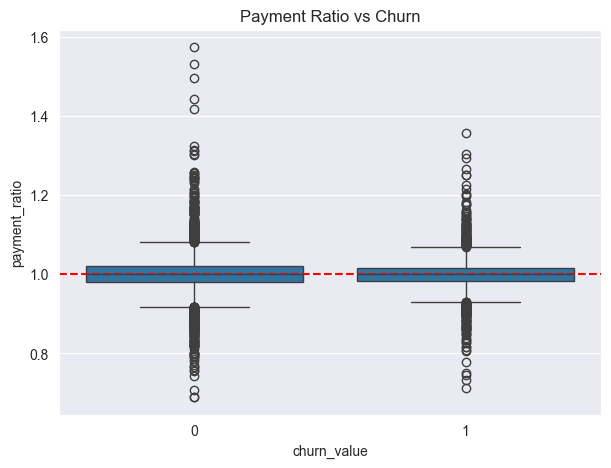

In [49]:
plt.figure(figsize=(7,5))

sns.boxplot(
    x="churn_value",
    y="payment_ratio",
    data=data
)

plt.axhline(1, color="red", linestyle="--")

plt.title("Payment Ratio vs Churn")

plt.show()

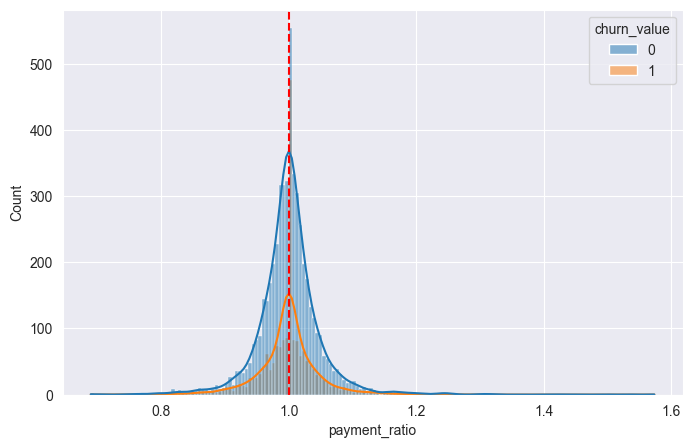

In [50]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=data,
    x="payment_ratio",
    hue="churn_value",
    kde=True
)

plt.axvline(1, color="red", linestyle="--")

plt.show()

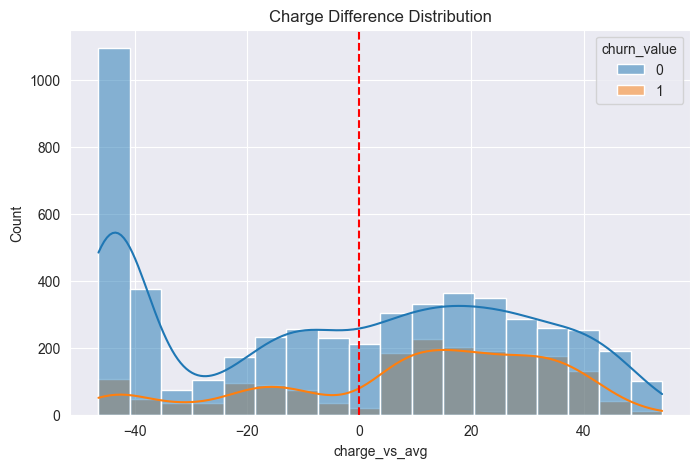

In [35]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=data,
    x="charge_vs_avg",
    hue="churn_value",
    kde=True
)

plt.axvline(0, color="red", linestyle="--")

plt.title("Charge Difference Distribution")
plt.show()

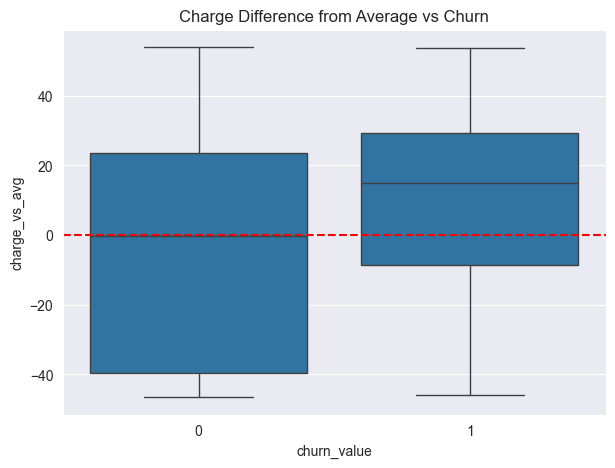

In [36]:
plt.figure(figsize=(7,5))

sns.boxplot(
    x="churn_value",
    y="charge_vs_avg",
    data=data
)

plt.title("Charge Difference from Average vs Churn")
plt.axhline(0, color="red", linestyle="--")

plt.show()

In [52]:
service_cols = [
    "phone_service", "online_security", "online_backup",
    "device_protection", "tech_support", "streaming_tv", "streaming_movies"
]

for col in service_cols:
    print(f"{col} \n", data[col].unique())
    print()

phone_service 
 <ArrowStringArray>
['Yes', 'No']
Length: 2, dtype: str

online_security 
 <ArrowStringArray>
['Yes', 'No']
Length: 2, dtype: str

online_backup 
 <ArrowStringArray>
['Yes', 'No']
Length: 2, dtype: str

device_protection 
 <ArrowStringArray>
['No', 'Yes']
Length: 2, dtype: str

tech_support 
 <ArrowStringArray>
['No', 'Yes']
Length: 2, dtype: str

streaming_tv 
 <ArrowStringArray>
['No', 'Yes']
Length: 2, dtype: str

streaming_movies 
 <ArrowStringArray>
['No', 'Yes']
Length: 2, dtype: str



In [54]:
data["total_services"] = (data[service_cols] == "Yes").sum(axis=1)

print(data[
    [
        "customerid",
        "total_services",
        "churn_value",
        "churn_reason"
    ]
].sample(100))

      customerid  total_services  churn_value  \
3303  4890-VMUAV               5            0   
2646  4026-SKKHW               2            0   
625   7548-SEPYI               4            1   
4834  5574-NXZIU               7            0   
4976  4385-ZKVNW               3            0   
3049  5816-JMLGY               6            0   
420   6032-KRXXO               3            1   
3454  4335-UPJSI               1            0   
3569  8499-BRXTD               1            0   
1919  7410-OIEDU               3            0   
5566  3528-HFRIQ               4            0   
6849  7672-VFMXZ               3            0   
2469  2040-OBMLJ               2            0   
6379  6198-PNNSZ               6            0   
2047  1984-GPTEH               1            0   
4183  7168-HDQHG               1            0   
310   3927-NLNRY               4            1   
3985  2452-KDRRH               4            0   
1914  0557-ASKVU               3            0   
5662  3727-OVPRY    

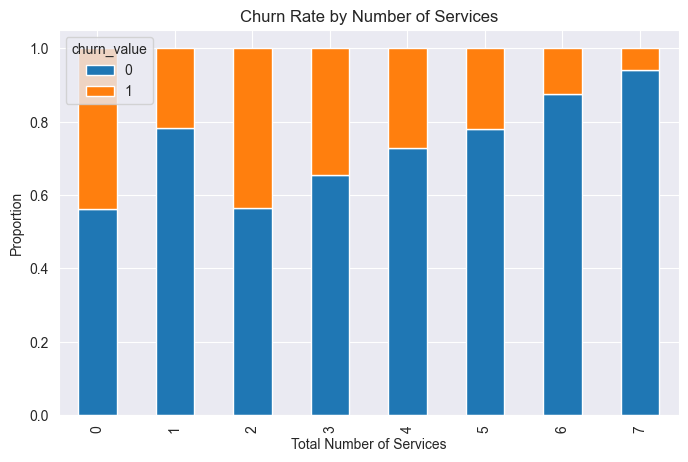

In [58]:
churn_rate = data.groupby("total_services")["churn_value"].value_counts(normalize=True).unstack()

churn_rate.plot(kind="bar", stacked=True, figsize=(8,5))
plt.title("Churn Rate by Number of Services")
plt.xlabel("Total Number of Services")
plt.ylabel("Proportion")
plt.show()

In [62]:
data["cost_per_service"] = np.where(
    data["total_services"] > 0,
    data["monthly_charges"] / data["total_services"],
    data["monthly_charges"]
)

print(data[
    [
        "customerid",
        "total_services",
        "cost_per_service",
        "churn_value",
        "monthly_charges",
        "churn_reason"
    ]
].sample(100))

      customerid  total_services  cost_per_service  churn_value  \
6659  0572-ZJKLT               5         19.930000            0   
496   4193-ORFCL               1         45.100000            1   
5854  8910-ICHIU               5         19.130000            0   
3749  4826-DXMUP               4         18.025000            0   
6797  6906-MPARY               4         22.400000            0   
849   4183-WCSEP               3         26.150000            1   
4667  7973-DZRKH               4         22.737500            0   
1669  7493-TPUWZ               2         39.575000            1   
1037  1304-NECVQ               2         39.275000            1   
6693  1548-FEHVL               5         21.240000            0   
6815  6898-RBTLU               5         15.860000            0   
771   4626-GYCZP               3         31.283333            1   
3275  2361-FJWNO               2         18.000000            0   
1500  4797-AXPXK               4         15.000000            

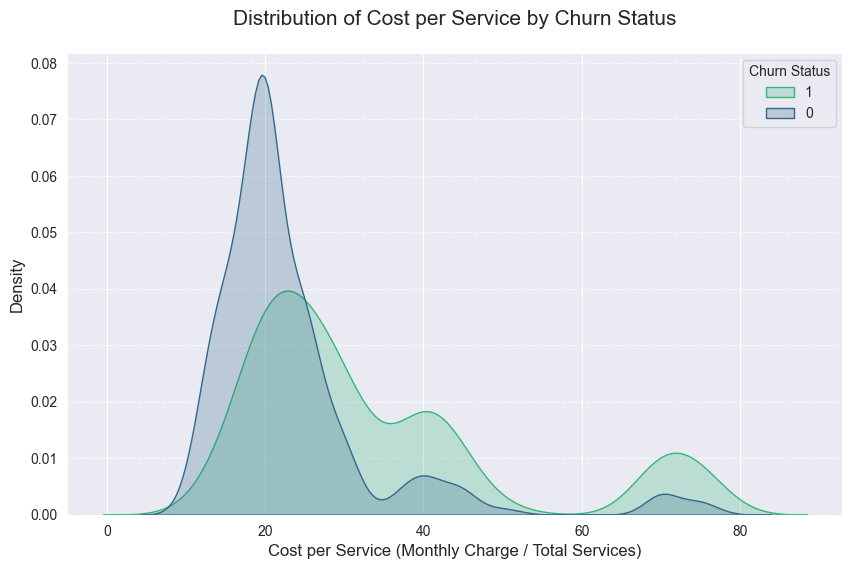

In [74]:
plt.figure(figsize=(10, 6))

sns.kdeplot(
    data=data,
    x="cost_per_service",
    hue="churn_value",
    fill=True,
    common_norm=False,
    palette="viridis"
)

plt.title("Distribution of Cost per Service by Churn Status", fontsize=15, pad=20)
plt.xlabel("Cost per Service (Monthly Charge / Total Services)", fontsize=12)
plt.ylabel("Density", fontsize=12)
plt.legend(title="Churn Status", labels=["1", "0"])
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

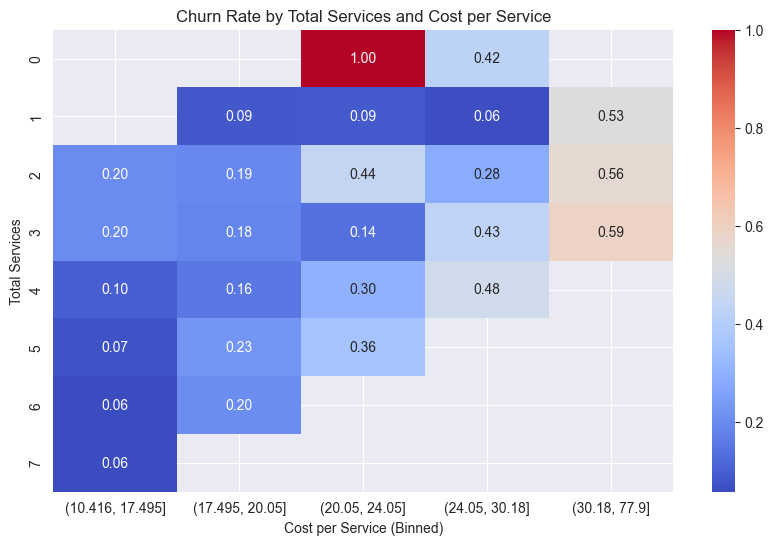

In [75]:
data["cost_bin"] = pd.qcut(data["cost_per_service"], 5)

pivot = data.pivot_table(
    values="churn_value",
    index="total_services",
    columns="cost_bin",
    aggfunc="mean"
)

plt.figure(figsize=(10,6))
sns.heatmap(pivot, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Churn Rate by Total Services and Cost per Service")
plt.xlabel("Cost per Service (Binned)")
plt.ylabel("Total Services")
plt.show()

In [7]:
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)

numeric_cols = [
    "tenure_months",
    "monthly_charges",
    "total_charges"
]

for col in numeric_cols:

    for churn_class in data["churn_value"].unique():

        subset = data[data["churn_value"] == churn_class]

        Q1 = subset[col].quantile(0.25)
        Q3 = subset[col].quantile(0.75)

        IQR = Q3 - Q1

        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        outliers = subset[
            (subset[col] < lower) |
            (subset[col] > upper)
        ]

        print("\n" + "="*60)
        print(f"Column: {col} | Churn: {churn_class}")
        print(f"Outlier Count: {len(outliers)}")
        print("="*60)

        print(
                outliers[
                    [
                        "customerid",
                        col,
                        "monthly_charges",
                        "total_charges",
                    ]
                ]
        )


Column: tenure_months | Churn: 1
Outlier Count: 23
      customerid  tenure_months  monthly_charges  total_charges
202   4853-RULSV             70           104.00        7250.15
248   2834-JRTUA             71           108.05        7532.15
339   0201-OAMXR             70           115.55        8127.60
751   4550-VBOFE             70           102.95        7101.50
793   7317-GGVPB             71           108.60        7690.90
815   8809-RIHDD             72           103.40        7372.65
901   0917-EZOLA             72           104.15        7689.95
916   0748-RDGGM             70           109.50        7534.65
1026  3886-CERTZ             72           109.25        8109.80
1091  6559-ILWKJ             71            49.35        3515.25
1182  8580-QVLOC             72            92.45        6440.25
1206  2889-FPWRM             72           117.80        8684.80
1429  3512-IZIKN             70            65.30        4759.75
1467  2225-ZRGSG             70            93.90    